### 1. Prerequisitos

#### 1.1 Paquetes
Instalación de paquetes requeridos para la ejecución adecuada del Notebook

In [1]:
!pip install --quiet -r requirements.txt

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


#### 1.2 Librerías
Importación de librerías requeridas para la ejecución adecuada del Notebook

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from joblib import dump
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,  classification_report
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier

#### 1.3 Variables comúnes
Asignación de variables que son utilizadas en diferentes puntos del Notebook

In [2]:
RANDOM_SEED = 42
DATA_PREPR = Path("./data-sources/pre-processed")
MODEL_PATH = Path("./models/tfidf")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

### 2. Datos

#### 2.1 Carga de datos
Carga de los datos a ser utilizados para el entrenamiento de los modelos

In [3]:
csv_files = sorted(DATA_PREPR.glob("data_chunk_*.csv"))
df_list = []
for f in csv_files:
    df_part = pd.read_csv(f)
    df_list.append(df_part)
data = pd.concat(df_list, ignore_index=True)
print(f'Registros totales cargados: {len(data)}')

Registros totales cargados: 58963


#### 2.2 Distribución
Distribución de los datos por cada uno de sus grupos (Texto Cientifico y PLS)

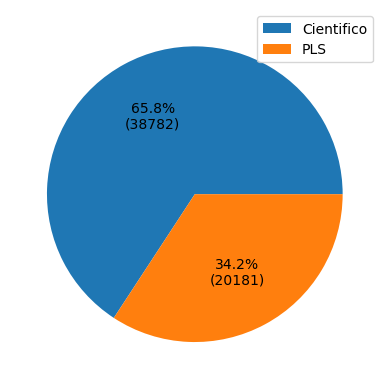

In [4]:
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

pls_label = {0: 'Cientifico',1: 'PLS'}

df_temp = data.groupby(['pls']).size().to_frame(name='count').reset_index()
df_temp['pls'] = df_temp['pls'].replace(pls_label)

plt.pie(df_temp['count'],autopct=autopct_format(df_temp['count']))
plt.legend(df_temp['pls'])
plt.show()

#### 2.3 División de los datos
División de datos en Entrenamiento, Test y Validación, sus porcentajes son 70%, 15% y 15% respectivamente

In [5]:
df_train, df_temp = train_test_split(data, test_size=0.3,random_state=RANDOM_SEED,stratify=data['pls'])
df_test, df_val = train_test_split(df_temp,test_size=0.5,random_state=RANDOM_SEED,stratify=df_temp['pls'])

x_train,y_train = df_train['text'],df_train['pls']
x_test,y_test = df_test['text'],df_test['pls']
x_val,y_val = df_val['text'],df_val['pls']

print(f'Cantidad de registros dataset entrenamiento: {len(df_train)}, porcentaje {len(df_train)/len(data):.0%}')
print(f'Cantidad de registros dataset validación: {len(df_val)}, porcentaje {len(df_val)/len(data):.0%}')
print(f'Cantidad de registros dataset test: {len(df_test)}, porcentaje {len(df_test)/len(data):.0%}')

Cantidad de registros dataset entrenamiento: 41274, porcentaje 70%
Cantidad de registros dataset validación: 8845, porcentaje 15%
Cantidad de registros dataset test: 8844, porcentaje 15%


### 3. Entrenamiento

#### 3.1 Clases requeridas
Definición de la clase `TextPreprocessor` para realizar la tokenizacion del texto y su limpieza.

In [6]:
class TextPreprocessor():

    def clean_light_text(self, text):
        text = re.sub(r'([\(\)"“”‘’!?.,:;()&^%$#@\-_\[\]\*])', r' \1 ', text)
        text = re.sub(r'\n+', ' ', text)
        return text
    
    def tokenize(self, text):
        return text.split()

Calculo de la proporción de balanceo en las clases

In [7]:
c_classes = np.unique(y_train)
c_weight=compute_class_weight(class_weight="balanced", classes=c_classes, y=y_train)
dict_weight = {}
for A, B in zip(c_classes, c_weight):
    dict_weight[int(A)] = float(B)

print(dict_weight)

{0: 0.7601944966294618, 1: 1.4608197069441495}


In [15]:
text_processor = TextPreprocessor()
pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf',LinearSVC())
    ])

tfid_block = {
    'vect__ngram_range': [(1, 2)],
    'vect__max_df': [0.8],
    'vect__min_df': [1],
    'vect__preprocessor': [text_processor.clean_light_text],
    'vect__tokenizer': [text_processor.tokenize],
    'vect__strip_accents': ['ascii'],
    'vect__token_pattern': [None],
}

param_grid = [
    {
        'clf': [LinearSVC()],
        'clf__C': [1],#[1, 2, 0.5]
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [LogisticRegression(max_iter=500)],
        'clf__solver': ['liblinear', 'saga'],
        'clf__penalty': ['l2'],
        'clf__C': [1],#[1.0, 0.5, 2.0]
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [RandomForestClassifier(random_state=RANDOM_SEED)],
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [None, 20, 40],
        'clf__min_samples_split': [2, 5],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [SGDClassifier(random_state=RANDOM_SEED)],
        'clf__loss': ['hinge', 'log_loss'],
        'clf__alpha': [1e-4, 5e-5, 1e-5],
        'clf__penalty': ['l2'],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
]

grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='f1_macro',verbose=2,n_jobs=-1)
grid_search.fit(x_train, y_train)
y_pred = grid_search.predict(x_test)

print("Mejores Hiperparámetros: ", grid_search.best_params_)
print("Mejor puntaje de validación cruzada: {:.5f}".format(grid_search.best_score_))

Fitting 5 folds for each of 21 candidates, totalling 105 fits
Mejores Hiperparámetros:  {'clf': SGDClassifier(random_state=42), 'clf__alpha': 1e-05, 'clf__class_weight': {0: 0.7601944966294618, 1: 1.4608197069441495}, 'clf__loss': 'hinge', 'clf__penalty': 'l2', 'vect__max_df': 0.8, 'vect__min_df': 1, 'vect__ngram_range': (1, 2), 'vect__preprocessor': <bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x000001388EFF5CD0>>, 'vect__strip_accents': 'ascii', 'vect__token_pattern': None, 'vect__tokenizer': <bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor object at 0x000001388EFF5CD0>>}
Mejor puntaje de validación cruzada: 0.99900


Definición del pipeline para el entrenamiento: Modelos y su parametrización, para el entrenamiento se consideraron los algoritmos:   
- LinearSVC
- LogisticRegression
- RandomForestClassifier
- SGDClassifier

El mejor modelo encontrado por medio de GridSearchCV es un **SGDClassifier**, esta es la matriz de confusion resultante

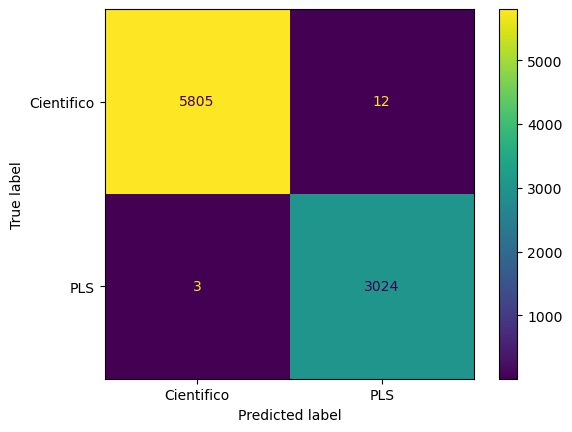

In [16]:
conf_mtx = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_mtx,display_labels=['Cientifico', 'PLS'])
disp.plot()
plt.show()

In [17]:
print(classification_report(y_test, y_pred,digits=4))

              precision    recall  f1-score   support

           0     0.9995    0.9979    0.9987      5817
           1     0.9960    0.9990    0.9975      3027

    accuracy                         0.9983      8844
   macro avg     0.9978    0.9985    0.9981      8844
weighted avg     0.9983    0.9983    0.9983      8844



In [18]:
y_pred_eval = grid_search.predict(x_val)
print(classification_report(y_val, y_pred_eval,digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9988    0.9992      5818
           1     0.9977    0.9993    0.9985      3027

    accuracy                         0.9990      8845
   macro avg     0.9987    0.9991    0.9989      8845
weighted avg     0.9990    0.9990    0.9990      8845



In [19]:
print(x_val.iloc[5])
print(f'Valor Original: {y_val.iloc[5]}')
print(f'Valor Predicho: {grid_search.predict(x_val.iloc[[5]])}')

Background
The risk of cytomegalovirus (CMV) infection in solid organ transplant recipients has resulted in the frequent use of prophylaxis with the aim of preventing the clinical syndrome associated with CMV infection. This is an update of a review first published in 2005 and updated in 2008. 
Objectives
To determine the benefits and harms of antiviral medications to prevent CMV disease and all‐cause mortality in solid organ transplant recipients. 
Search methods
We searched MEDLINE, EMBASE and the Cochrane Central Registry of Controlled Trials (CENTRAL) in The Cochrane Library to February 2004 for the first version of this review. The Cochrane Renal Group's specialised register was searched to February 2007 and to July 2011 for the first and current updates of the review without language restriction. 
Selection criteria
We included randomised controlled trials (RCTs) and quasi‐RCTs comparing antiviral medications with placebo or no treatment, comparing different antiviral medications

Se guarda el modelo en la ruta **models/tfidf**

In [20]:
best_model = grid_search.best_estimator_
dump(best_model, MODEL_PATH/"best_model_SGD.joblib")  

['models\\tfidf\\best_model_SGD.joblib']

In [9]:
# ======= MODELOS EXTRA + HALVING GRID =======
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier, RidgeClassifier, Perceptron
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np, pandas as pd, warnings

warnings.filterwarnings("ignore")

# Defaults por si ejecutas esta celda aislada (en tu notebook real ya existen)
try: RANDOM_SEED
except NameError: RANDOM_SEED = 123
try: text_processor
except NameError:
    class _TP:
        def clean_light_text(self, s): return s
        def tokenize(self, s): return s.split()
    text_processor = _TP()
try: dict_weight
except NameError: dict_weight = None

tfid_block = {
    'vect__ngram_range': [(1, 1), (1, 2)],
    'vect__max_df': [0.8, 0.9],
    'vect__min_df': [1, 2],
    'vect__preprocessor': [text_processor.clean_light_text],
    'vect__tokenizer': [text_processor.tokenize],
    'vect__strip_accents': ['ascii'],
    'vect__token_pattern': [None],
    'vect__lowercase': [True],
}

grids_extra = [
    {
        'name': 'RidgeClassifier',
        'estimator': Pipeline([
            ('vect', TfidfVectorizer()),
            ('clf', RidgeClassifier(random_state=RANDOM_SEED, solver='lsqr'))
        ]),
        'param_grid': {
            'clf__alpha': [0.5, 1.0, 2.0],
            'clf__solver': ['lsqr', 'sag'],
            'clf__class_weight': [dict_weight],
            **tfid_block
        }
    },
    {
        'name': 'PassiveAggressive',
        'estimator': Pipeline([
            ('vect', TfidfVectorizer()),
            ('clf', PassiveAggressiveClassifier(random_state=RANDOM_SEED))
        ]),
        'param_grid': {
            'clf__C': [0.5, 1.0, 2.0],
            'clf__max_iter': [2000],
            'clf__class_weight': [dict_weight],
            **tfid_block
        }
    },
    {
        'name': 'Perceptron',
        'estimator': Pipeline([
            ('vect', TfidfVectorizer()),
            ('clf', Perceptron(random_state=RANDOM_SEED))
        ]),
        'param_grid': {
            'clf__penalty': [None, 'l2'],
            'clf__alpha': [1e-4, 1e-3],
            'clf__max_iter': [2000],
            'clf__class_weight': [dict_weight],
            **tfid_block
        }
    },
    {
        'name': 'ComplementNB',
        'estimator': Pipeline([
            ('vect', TfidfVectorizer()),
            ('clf', ComplementNB())
        ]),
        'param_grid': {
            'clf__alpha': [0.1, 0.5, 1.0],
            **tfid_block
        }
    },
    {
        'name': 'MultinomialNB',
        'estimator': Pipeline([
            ('vect', TfidfVectorizer()),
            ('clf', MultinomialNB())
        ]),
        'param_grid': {
            'clf__alpha': [0.1, 0.5, 1.0],
            **tfid_block
        }
    },
]

def _run_halving(spec):
    search = HalvingGridSearchCV(
        spec['estimator'], spec['param_grid'],
        factor=3, scoring='f1_macro', cv=5, n_jobs=6,
        verbose=2, random_state=RANDOM_SEED
    )
    search.fit(x_train, y_train)
    return search

rows, best_models = [], {}
for spec in grids_extra:
    search = _run_halving(spec)
    best = search.best_estimator_
    y_pred = best.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    rows.append({
        'model': spec['name'],
        'cv_best_f1_macro': search.best_score_,
        'test_accuracy': acc,
        'test_precision_macro': prec,
        'test_recall_macro': rec,
        'test_f1_macro': f1,
        'best_params': search.best_params_
    })
    best_models[spec['name']] = best

df_results = pd.DataFrame(rows).sort_values(by='test_f1_macro', ascending=False).reset_index(drop=True)
df_results


n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1528
max_resources_: 41274
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 48
n_resources: 1528
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 1
n_candidates: 16
n_resources: 4584
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 2
n_candidates: 6
n_resources: 13752
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 3
n_candidates: 2
n_resources: 41256
Fitting 5 folds for each of 2 candidates, totalling 10 fits
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 4586
max_resources_: 41274
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 24
n_resources: 4586
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 8
n_resources: 13758
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
it

,model,cv_best_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,best_params
0,RidgeClassifier,0.999219,0.999209,0.999003,0.999240,0.999121,"{'clf__alpha': 0.5, 'clf__class_weight': {0: 0..."
1,PassiveAggressive,0.999139,0.999095,0.998838,0.999154,0.998996,"{'clf__C': 1.0, 'clf__class_weight': {0: 0.760..."
2,Perceptron,0.997928,0.997739,0.997023,0.997964,0.997491,"{'clf__alpha': 0.001, 'clf__class_weight': {0:..."
3,ComplementNB,0.992575,0.993668,0.994563,0.991384,0.992946,"{'clf__alpha': 0.1, 'vect__lowercase': True, '..."
4,MultinomialNB,0.990290,0.992537,0.994050,0.989415,0.991674,"{'clf__alpha': 0.1, 'vect__lowercase': True, '..."


In [10]:
output_path = MODEL_PATH / "resultados_modelos_extra.csv"
df_results.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Resultados guardados en: {output_path}")

Resultados guardados en: models\tfidf\resultados_modelos_extra.csv


Mejor modelo según test_f1_macro: RidgeClassifier


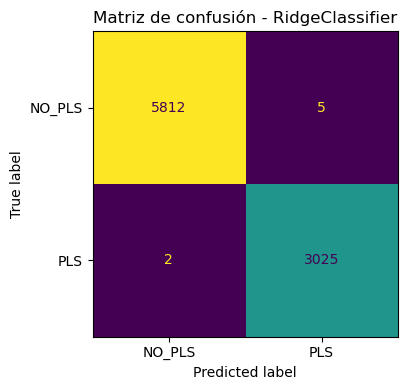

              precision    recall  f1-score   support

      NO_PLS      1.000     0.999     0.999      5817
         PLS      0.998     0.999     0.999      3027

    accuracy                          0.999      8844
   macro avg      0.999     0.999     0.999      8844
weighted avg      0.999     0.999     0.999      8844


✓ Matriz de confusión guardada en: models\tfidf\confusion_matrix_best.png
✓ Classification report guardado en: models\tfidf\classification_report_best.txt


In [11]:
# ====== MATRIZ DE CONFUSIÓN + CLASSIFICATION REPORT DEL MEJOR MODELO ======
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from pathlib import Path
import os

# 1) Elegimos la métrica para seleccionar el mejor modelo
metric = 'test_f1_macro' if 'test_f1_macro' in df_results.columns else 'cv_best_f1_macro'
best_idx = int(np.argmax(df_results[metric].values))
best_name = df_results.loc[best_idx, 'model']
best_model = best_models[best_name]

print(f"Mejor modelo según {metric}: {best_name}")
y_pred = best_model.predict(x_test)

# 2) Nombres de clases (opcional): intenta asignar etiquetas legibles
#    Si ya tienes 0/1 como NO_PLS/PLS, puedes definir manualmente:
# class_names = ["NO_PLS", "PLS"]
# Si no, intentamos inferirlas de y_test
classes_sorted = np.unique(y_test)
try:
    # Si tus etiquetas ya son 0/1 y quieres nombres:
    class_names = ["NO_PLS" if c in [0, "0", "no_pls", "NO_PLS", "No"] else "PLS" for c in classes_sorted]
    # Si prefieres dejar los valores originales:
    # class_names = [str(c) for c in classes_sorted]
except Exception:
    class_names = [str(c) for c in classes_sorted]

# 3) Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes_sorted)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión - {best_name}")
plt.tight_layout()
plt.show()

# 4) Classification report (en consola) y guardado a archivo
report_txt = classification_report(y_test, y_pred, target_names=class_names, digits=3)
print(report_txt)

# 5) Guardar artefactos
# Usa tu MODEL_PATH si existe; si no, guarda en el directorio actual
out_dir = MODEL_PATH if 'MODEL_PATH' in globals() and os.path.isdir(MODEL_PATH) else Path(".")
(cm_path, rpt_path) = (Path(out_dir) / "confusion_matrix_best.png",
                       Path(out_dir) / "classification_report_best.txt")

# Guardar la figura de la matriz
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
# Guardar el classification report en texto
with open(rpt_path, "w", encoding="utf-8") as f:
    f.write(f"Modelo: {best_name}\nMétrica selección: {metric}\n\n")
    f.write(report_txt)

print(f"\n✓ Matriz de confusión guardada en: {cm_path}")
print(f"✓ Classification report guardado en: {rpt_path}")
